# Qwen3-VL-4B Fine-tuning – Agentic Format
Train from scratch on the two-turn inspection format: Round 1 scouts regions, Round 2 gives final verdict. Single-turn adapter would bias toward direct answers; fresh training learns the new reasoning pattern.

In [1]:
import json
import re
import sys
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from datasets import Dataset
from transformers import EarlyStoppingCallback
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig
from qwen_vl_utils import process_vision_info

ROOT       = Path(".").resolve().parent
CLEAN_DIR  = ROOT / "data" / "clean"
MESSY_DIR  = ROOT / "data" / "messy"
MASK_DIR   = ROOT / "data" / "masks"
CROP_DIR   = ROOT / "data" / "crops"
OUTPUT_DIR = ROOT / "outputs" / "lora_adapter_agent"

sys.path.insert(0, str(ROOT))

c:\Users\ranen\Projects\roomaudit\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\ranen\AppData\Local\Temp\ipykernel_15976\3931615384.py:12: UserWarning: WARNING: Unsloth should be imported before [transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastVisionModel


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


W0308 04:52:28.869000 15976 Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


🦥 Unsloth Zoo will now patch everything to make training faster!


## Config

In [2]:
MODEL_ID      = "unsloth/Qwen3-VL-4B-Instruct-unsloth-bnb-4bit"

LORA_R      = 32
LORA_ALPHA  = 32
LR          = 5e-5
EPOCHS      = 15
BATCH_SIZE  = 2
GRAD_ACCUM  = 4
MAX_SEQ_LEN = 4096
EVAL_SPLIT  = 0.15

## Prompts (from backend/agent.py)

In [3]:
SCOUT_SYSTEM_PROMPT = (
    "You are a hotel room cleanliness inspector. "
    "Respond ONLY with valid JSON."
)

SCOUT_QUESTION = (
    "Before assessing this hotel room, identify 1-2 specific regions you want to inspect more closely. "
    "Choose regions that would give the most useful evidence about cleanliness: "
    "beds, pillows, floors, bins, towels, chairs are common inspection areas. "
    "Respond ONLY with this schema: "
    '{"regions": [{"region": [x1, y1, x2, y2], "reason": "..."}, ...]} '
    "where coordinates are fractions of the image size (0.0 to 1.0), "
    "x1,y1 is top-left and x2,y2 is bottom-right. Identify exactly 1 or 2 regions."
)

CROP_FOLLOWUP = (
    "Here are the regions you requested. "
    "Now give your final cleanliness assessment using only this schema: "
    '{"clean": true/false, "defects": [{"object": "...", "type": "...", "description": "..."}]} '
    "Valid objects: pillow, bed_sheet, blanket, floor, carpet, chair, desk, mirror, sofa, bath_towel, bin, window. "
    "Valid defect types: stain, hair, debris, litter, not_emptied, dirty. "
    "If no defects are visible in the inspected regions, set clean=true and defects=[]."
)

## Mask Utilities

In [4]:
def mask_to_bbox(mask: np.ndarray):
    """Binary mask (H, W) → normalized [x1,y1,x2,y2] with 10% padding. Returns None if mask is empty."""
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    if not rows.any():
        return None
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    h, w = mask.shape
    px = (cmax - cmin) * 0.1
    py = (rmax - rmin) * 0.1
    return [
        round(max(0.0, (cmin - px) / w), 4),
        round(max(0.0, (rmin - py) / h), 4),
        round(min(1.0, (cmax + px) / w), 4),
        round(min(1.0, (rmax + py) / h), 4),
    ]

def top_n_regions(npz_path: Path, preferred_obj: str = None, n=2):
    """Load .npz, compute bboxes, return up to n (obj_key, bbox) pairs.
    preferred_obj goes first if present; rest sorted by mask pixel count (largest = most inspectable)."""
    npz = np.load(npz_path)
    entries = []
    for key in npz.files:
        # SAM3 stores masks as (1, H, W) — squeeze to (H, W)
        mask = npz[key].squeeze().astype(bool)
        bbox = mask_to_bbox(mask)
        if bbox is not None:
            entries.append((key, int(mask.sum()), bbox))
    # Sort: preferred first, then largest mask
    entries.sort(key=lambda x: (x[0] != preferred_obj, -x[1]))
    return [(k, b) for k, _, b in entries[:n]]

## Crop Generation

In [5]:
def save_crop(img: Image.Image, bbox: list, out_path: Path) -> Path:
    """Extract region from image using normalized bbox and save."""
    w, h = img.size
    x1, y1, x2, y2 = bbox
    crop = img.crop((int(x1*w), int(y1*h), int(x2*w), int(y2*h)))
    out_path.parent.mkdir(parents=True, exist_ok=True)
    crop.save(out_path)
    return out_path

## Agentic Sample Builder

In [6]:
def make_agentic_sample(full_img_path, crop_paths, regions, is_clean, defects=None):
    """Build a two-turn agentic conversation sample.
    Turn 1: user shows full image + scout question, assistant returns region list.
    Turn 2: user shows crops + followup question, assistant returns final verdict."""
    scout_response = {
        "regions": [
            {"region": r["bbox"], "reason": r["reason"]}
            for r in regions
        ]
    }
    final_response = {
        "clean": True,
        "defects": []
    } if is_clean else {
        "clean": False,
        "defects": [
            {"object": d["object"], "type": d["label"], "description": d["prompt"]}
            for d in defects
        ]
    }
    crop_content = [
        {"type": "image", "image": str(p)}
        for p in crop_paths
    ]
    crop_content.append({"type": "text", "text": CROP_FOLLOWUP})
    return {
        "messages": [
            {"role": "system", "content": [{"type": "text", "text": SCOUT_SYSTEM_PROMPT}]},
            {"role": "user", "content": [
                {"type": "image", "image": str(full_img_path)},
                {"type": "text", "text": SCOUT_QUESTION},
            ]},
            {"role": "assistant", "content": [{"type": "text", "text": json.dumps(scout_response)}]},
            {"role": "user", "content": crop_content},
            {"role": "assistant", "content": [{"type": "text", "text": json.dumps(final_response)}]},
        ]
    }

## Build Dataset

In [7]:
manifest = json.loads((MESSY_DIR / "manifest.json").read_text())
rows = []
CROP_DIR.mkdir(exist_ok=True)

print("Building messy samples...")
# Messy agentic samples: use primary defect object's mask as region 1, next-best as region 2
for img_name, variants in manifest.items():
    base = Path(img_name).stem
    npz_path = MASK_DIR / f"{base}.npz"
    if not npz_path.exists():
        continue
    for vi, variant in enumerate(variants):
        out_path = MESSY_DIR / variant["output"]
        if not out_path.exists():
            continue
        primary_obj = variant["defects"][0]["object"] if variant["defects"] else None
        region_pairs = top_n_regions(npz_path, preferred_obj=primary_obj, n=2)
        if not region_pairs:
            continue
        img = Image.open(out_path)
        crops, region_meta = [], []
        for ci, (obj_key, bbox) in enumerate(region_pairs):
            crop_path = CROP_DIR / f"{base}_v{vi}_c{ci}.jpg"
            save_crop(img, bbox, crop_path)
            crops.append(crop_path)
            region_meta.append({"bbox": bbox, "reason": f"Inspecting {obj_key.replace('_', ' ')} area"})
        rows.append(make_agentic_sample(out_path, crops, region_meta, is_clean=False, defects=variant["defects"]))

print(f"Messy samples: {len([r for r in rows])}")

# Defect-prone objects to prioritise for clean crops — model must learn "I checked the pillow; it's clean"
CLEAN_PREFERRED_OBJS = ["pillow", "bed_sheet", "floor", "carpet", "chair", "bin", "bath_towel"]

print("Building clean samples (3× with cycling preferred objects)...")
for img_path in sorted(CLEAN_DIR.glob("*.jpg")):
    base = img_path.stem
    npz_path = MASK_DIR / f"{base}.npz"
    if not npz_path.exists():
        continue
    npz_keys = set(np.load(npz_path).files)
    avail_preferred = [obj for obj in CLEAN_PREFERRED_OBJS if obj in npz_keys]
    img = Image.open(img_path)
    for ri in range(3):
        # Each repeat uses a different preferred object to generate genuinely different crop pairs
        pref = avail_preferred[ri] if ri < len(avail_preferred) else None
        region_pairs = top_n_regions(npz_path, preferred_obj=pref, n=2)
        if not region_pairs:
            continue
        crops, region_meta = [], []
        for ci, (obj_key, bbox) in enumerate(region_pairs):
            crop_path = CROP_DIR / f"{base}_clean_r{ri}_c{ci}.jpg"
            save_crop(img, bbox, crop_path)
            crops.append(crop_path)
            region_meta.append({"bbox": bbox, "reason": f"Inspecting {obj_key.replace('_', ' ')} area"})
        rows.append(make_agentic_sample(img_path, crops, region_meta, is_clean=True))

random.shuffle(rows)
n_eval   = max(1, int(len(rows) * EVAL_SPLIT))
train_ds = Dataset.from_list(rows[n_eval:])
eval_ds  = Dataset.from_list(rows[:n_eval])

print(f"\nDataset split:")
print(f"  Train: {len(train_ds)}")
print(f"  Eval:  {len(eval_ds)}")
print(f"  Total: {len(rows)}")

Building messy samples...
Messy samples: 654
Building clean samples (3× with cycling preferred objects)...

Dataset split:
  Train: 1112
  Eval:  196
  Total: 1308


## Load Model

In [8]:
print(f"Loading model from {MODEL_ID}...")
model, tokenizer = FastVisionModel.from_pretrained(
    MODEL_ID,
    load_in_4bit=True,
    use_gradient_checkpointing="unsloth",
    max_seq_length=MAX_SEQ_LEN,
)

model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers=False,
    finetune_language_layers=True,
    finetune_attention_modules=True,
    finetune_mlp_modules=True,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=0.05,
    bias="none",
    use_rslora=False,
)

print("Model ready for training.")

Loading model from unsloth/Qwen3-VL-4B-Instruct-unsloth-bnb-4bit...
==((====))==  Unsloth 2026.2.1: Fast Qwen3_Vl patching. Transformers: 4.57.6.
   \\   /|    NVIDIA GeForce RTX 5070 Ti. Num GPUs = 1. Max memory: 15.92 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.


Model ready for training.


## Train

In [9]:
FastVisionModel.for_training(model)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    data_collator=UnslothVisionDataCollator(model, tokenizer),
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=6)],
    args=SFTConfig(
        per_device_train_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUM,
        num_train_epochs=EPOCHS,
        learning_rate=LR,
        lr_scheduler_type="cosine",
        warmup_ratio=0.05,
        weight_decay=0.05,
        max_grad_norm=0.3,
        bf16=torch.cuda.is_bf16_supported(),
        fp16=not torch.cuda.is_bf16_supported(),
        optim="adamw_8bit",
        max_seq_length=MAX_SEQ_LEN,
        eval_strategy="steps",
        eval_steps=25,
        save_steps=25,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        output_dir=str(OUTPUT_DIR / "checkpoints"),
        report_to="none",
        logging_steps=10,
        dataset_text_field="",
        dataset_kwargs={"skip_prepare_dataset": True},
        remove_unused_columns=False,
    ),
)

trainer.train()

Unsloth: Model does not have a default image size - using 512


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,112 | Num Epochs = 15 | Total steps = 2,085
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 66,060,288 of 4,503,876,096 (1.47% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
25,2.684300,2.136158
50,1.247400,1.000837
75,0.295700,0.205172
100,0.166100,0.160089
125,0.145000,0.136219
150,0.133400,0.127063
175,0.124500,0.118226
200,0.121200,0.117205
225,0.119400,0.113072
250,0.113500,0.111268


Unsloth: Not an error, but Qwen3VLForConditionalGeneration does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


TrainOutput(global_step=1225, training_loss=0.1584417416429033, metrics={'train_runtime': 7596.1313, 'train_samples_per_second': 2.196, 'train_steps_per_second': 0.274, 'total_flos': 2.1036779103808512e+17, 'train_loss': 0.1584417416429033, 'epoch': 8.81294964028777})

## Save Adapter

In [10]:
model.save_pretrained(str(OUTPUT_DIR))
tokenizer.save_pretrained(str(OUTPUT_DIR))
print(f"Adapter saved to {OUTPUT_DIR}")

Adapter saved to C:\Users\ranen\Projects\roomaudit\outputs\lora_adapter_agent


## Evaluate — Two-Turn Agentic Flow

In [11]:
best_ckpt = trainer.state.best_model_checkpoint
best_step = int(Path(best_ckpt).name.split("-")[-1]) if best_ckpt else None
print(f"Best checkpoint: step {best_step}, eval_loss {trainer.state.best_metric:.6f}")
print("Running eval on best checkpoint...")
FastVisionModel.for_inference(model)

y_true_clean, y_pred_clean = [], []
y_true_messy, y_pred_messy = [], []
fallback_count = 0

def clean_messages(messages):
    result = []
    for msg in messages:
        clean_content = [
            {k: v for k, v in item.items() if v is not None}
            for item in msg["content"]
        ]
        result.append({**msg, "content": clean_content})
    return result

for sample in eval_ds:
    messages = sample["messages"]
    # Ground truth is in the final assistant message (Turn 2 verdict)
    gt = json.loads(messages[-1]["content"][0]["text"])
    gt_clean = gt["clean"]

    # Inference: Round 1 — scout regions
    round1_messages = clean_messages(messages[:2])
    text = tokenizer.apply_chat_template(round1_messages, tokenize=False, add_generation_prompt=True)
    image_inputs, _ = process_vision_info(round1_messages)
    inputs = tokenizer(
        text=[text], images=image_inputs, padding=True, return_tensors="pt"
    ).to("cuda")

    out_ids = model.generate(
        **inputs, max_new_tokens=256,
        do_sample=True, temperature=0.1, repetition_penalty=1.05,
    )
    gen_ids = [o[len(i):] for i, o in zip(inputs.input_ids, out_ids)]
    round1_text = tokenizer.batch_decode(gen_ids, skip_special_tokens=True)[0].strip()

    # Parse regions from Round 1
    try:
        match = re.search(r"\{.*\}", round1_text, re.DOTALL)
        round1_json = json.loads(match.group()) if match else {}
        regions = round1_json.get("regions", [])
    except Exception:
        regions = []

    # Fallback: if Round 1 failed, conservatively predict messy
    if not regions:
        fallback_count += 1
        if gt_clean:
            y_true_clean.append(1)
            y_pred_clean.append(0)  # False positive (predicted messy)
        else:
            y_true_messy.append(1)
            y_pred_messy.append(1)  # True positive
        continue

    # Round 2 — full conversation with crops
    # Build: [system, user_full, assistant_scout, user_crops]
    round2_messages = clean_messages(messages[:3])  # system + user_full + assistant_scout
    round2_messages[2]["content"] = [{"type": "text", "text": round1_text}]  # Use generated scout response
    round2_messages.append(clean_messages([messages[3]])[0])  # Add user_crops message

    text = tokenizer.apply_chat_template(round2_messages, tokenize=False, add_generation_prompt=True)
    image_inputs, _ = process_vision_info(round2_messages)
    inputs = tokenizer(
        text=[text], images=image_inputs, padding=True, return_tensors="pt"
    ).to("cuda")

    out_ids = model.generate(
        **inputs, max_new_tokens=256,
        do_sample=True, temperature=0.1, repetition_penalty=1.05,
    )
    gen_ids = [o[len(i):] for i, o in zip(inputs.input_ids, out_ids)]
    round2_text = tokenizer.batch_decode(gen_ids, skip_special_tokens=True)[0].strip()

    # Parse final verdict
    try:
        match = re.search(r"\{.*\}", round2_text, re.DOTALL)
        pred = json.loads(match.group()) if match else {}
        pred_clean = pred.get("clean", True)
    except Exception:
        pred_clean = True

    if gt_clean:
        y_true_clean.append(1)
        y_pred_clean.append(1 if pred_clean else 0)
    else:
        y_true_messy.append(1)
        y_pred_messy.append(0 if pred_clean else 1)

print(f"Eval samples processed: {len(y_true_clean) + len(y_true_messy)} ({fallback_count} Round 1 fallbacks)")

Best checkpoint: step 1075, eval_loss 0.051568
Running eval on best checkpoint...
Eval samples processed: 196 (1 Round 1 fallbacks)


## Metrics and Confusion Matrix

In [12]:
# Overall metrics
y_true_all = [0] * len(y_true_clean) + [1] * len(y_true_messy)
y_pred_all = y_pred_clean + y_pred_messy

tp = sum(1 for t, p in zip(y_true_all, y_pred_all) if t == 1 and p == 1)
fp = sum(1 for t, p in zip(y_true_all, y_pred_all) if t == 0 and p == 1)
tn = sum(1 for t, p in zip(y_true_all, y_pred_all) if t == 0 and p == 0)
fn = sum(1 for t, p in zip(y_true_all, y_pred_all) if t == 1 and p == 0)

accuracy  = (tp + tn) / len(y_true_all) if y_true_all else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1:        {f1:.3f}")

print(f"\nConfusion matrix:")
print(f"  TN={tn}  FP={fp}")
print(f"  FN={fn}  TP={tp}")

# Per-class breakdown
clean_correct = sum(y_pred_clean)
clean_total   = len(y_pred_clean)
messy_correct = sum(y_pred_messy)
messy_total   = len(y_pred_messy)

print(f"\nPer-class:")
if clean_total:
    print(f"  Clean: {clean_correct}/{clean_total} correct ({100*clean_correct/clean_total:.1f}%)")
if messy_total:
    print(f"  Messy: {messy_correct}/{messy_total} correct ({100*messy_correct/messy_total:.1f}%)")

print(f"\nSingle-turn baseline (run 4):  Precision 0.676  Recall 0.906  F1 0.774")

Accuracy:  0.663
Precision: 0.622
Recall:    0.902
F1:        0.736

Confusion matrix:
  TN=38  FP=56
  FN=10  TP=92

Per-class:
  Clean: 56/94 correct (59.6%)
  Messy: 92/102 correct (90.2%)

Single-turn baseline (run 4):  Precision 0.676  Recall 0.906  F1 0.774


## Plots

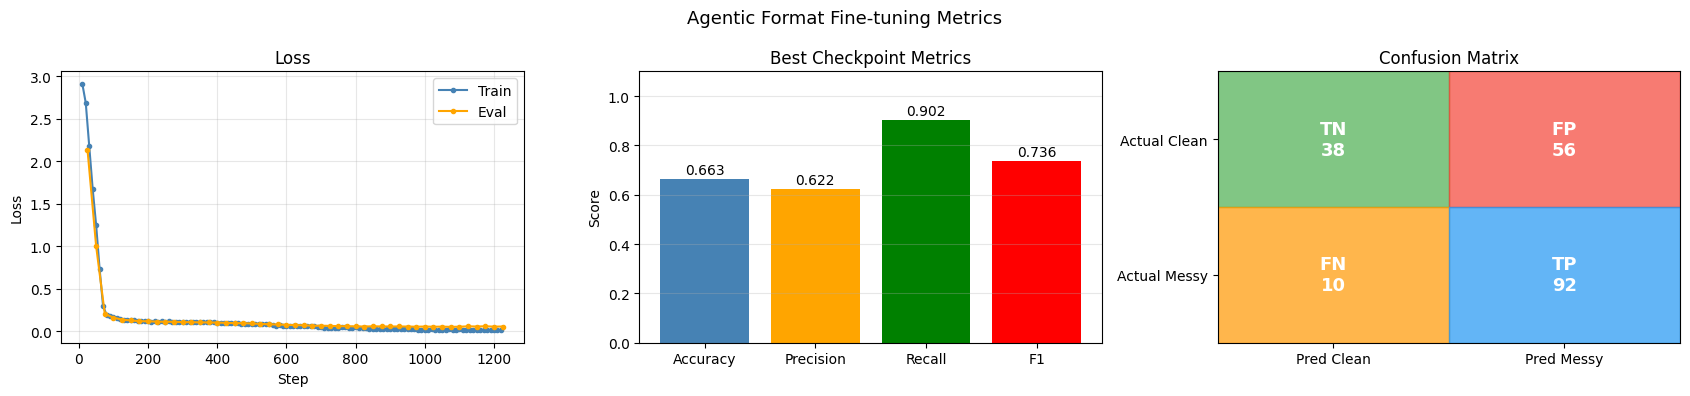

In [13]:
log = trainer.state.log_history
train_steps = [e["step"] for e in log if "loss" in e and "eval_loss" not in e]
train_loss  = [e["loss"] for e in log if "loss" in e and "eval_loss" not in e]
eval_steps  = [e["step"] for e in log if "eval_loss" in e]
eval_loss   = [e["eval_loss"] for e in log if "eval_loss" in e]

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle("Agentic Format Fine-tuning Metrics", fontsize=13)

axes[0].plot(train_steps, train_loss, label="Train", color="steelblue", marker="o", markersize=3)
axes[0].plot(eval_steps,  eval_loss,  label="Eval",  color="orange",   marker="o", markersize=3)
axes[0].set_title("Loss")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

labels = ["Accuracy", "Precision", "Recall", "F1"]
values = [accuracy, precision, recall, f1]
colors = ["steelblue", "orange", "green", "red"]
bars = axes[1].bar(labels, values, color=colors)
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=10)
axes[1].set_ylim(0, 1.1)
axes[1].set_title("Best Checkpoint Metrics")
axes[1].set_ylabel("Score")
axes[1].grid(True, alpha=0.3, axis="y")

# Confusion matrix
cm = [[tn, fp], [fn, tp]]
cm_labels = [["TN", "FP"], ["FN", "TP"]]
cm_colors = [["#4CAF50", "#F44336"], ["#FF9800", "#2196F3"]]
ax = axes[2]
for i in range(2):
    for j in range(2):
        ax.add_patch(plt.Rectangle((j, 1 - i), 1, 1, color=cm_colors[i][j], alpha=0.7))
        ax.text(j + 0.5, 1.5 - i, f"{cm_labels[i][j]}\n{cm[i][j]}",
                ha="center", va="center", fontsize=13, fontweight="bold", color="white")
ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5])
ax.set_xticklabels(["Pred Clean", "Pred Messy"])
ax.set_yticks([0.5, 1.5])
ax.set_yticklabels(["Actual Messy", "Actual Clean"])
ax.set_title("Confusion Matrix")

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "metrics.png"), dpi=150)
plt.show()